## Logistic Regression

### Import necessary libraries and dataset

In [47]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,roc_auc_score
from matplotlib import pyplot as plt

claimants_data = pd.read_csv("claimants.csv")
claimants_data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


### Data Understanding

In [8]:
claimants_data.shape

(1340, 7)

In [9]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [10]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

### Data Preparation

#### 4.1 Data cleaning

In [11]:
claimants_data.dropna(inplace = True)
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [12]:
claimants_data.shape

(1096, 7)

In [13]:
1340-1096

244

#### 4.2 Separate your input and output

In [14]:
X = claimants_data.drop(labels = ["CASENUM","ATTORNEY"], axis = 1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [15]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

### 5. Model Buidling

In [22]:
logistic_model = LogisticRegression()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, shuffle = True, random_state=34)

In [36]:
y_test

627     0
1125    1
1124    1
1025    0
481     0
       ..
658     0
1257    1
1015    0
1114    0
990     0
Name: ATTORNEY, Length: 220, dtype: int64

### 6. Model Training

In [24]:
logistic_model.fit(X_train,y_train)

LogisticRegression()

### 7. Model Testing

#### 7.1 Training Data

In [33]:
y_pred_train = logistic_model.predict(X_train)
y_pred_train

array([0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

#### 7.2 Testing Data

In [34]:
y_pred_test = logistic_model.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0],
      dtype=int64)

### 8. Model Evaluation

#### 8.1 Training data's evaluation metrics

In [38]:
print(confusion_matrix(y_train,y_pred_train))

[[297 156]
 [ 99 324]]


In [39]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.66      0.70       453
           1       0.68      0.77      0.72       423

    accuracy                           0.71       876
   macro avg       0.71      0.71      0.71       876
weighted avg       0.71      0.71      0.71       876



#### 8.2 Test data's evaluation metrics

In [40]:
accuracy_score(y_test,y_pred_test)

0.6818181818181818

In [42]:
print(confusion_matrix(y_test,y_pred_test))

[[78 47]
 [23 72]]


#### ROC_Curve Training

AUC SCORE: 0.7107932929406792


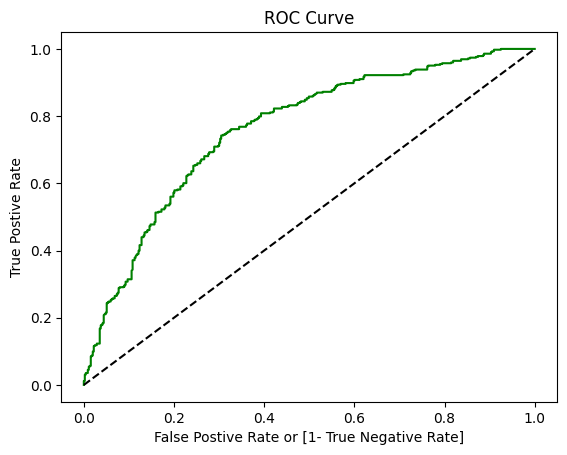

In [58]:
fpr, tpr, thresholds = roc_curve(y_train, logistic_model.predict_proba(X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print("AUC SCORE:",auc)

plt.plot(fpr,tpr, color = 'green', label = 'logit model (area = %0.2f)' %auc)
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel('False Postive Rate or [1- True Negative Rate]')
plt.ylabel('True Postive Rate')
plt.show()

AUC SCORE: 0.6909473684210526


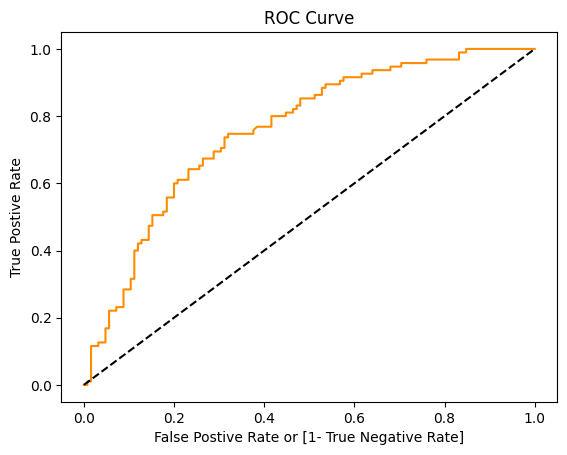

In [59]:
fpr, tpr, thresholds = roc_curve(y_test, logistic_model.predict_proba(X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print("AUC SCORE:",auc)

plt.plot(fpr,tpr, color = 'darkorange', label = 'logit model (area = %0.2f)' %auc)
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel('False Postive Rate or [1- True Negative Rate]')
plt.ylabel('True Postive Rate')
plt.show()